# Model Training and Evaluation

In this stage, machine learning models are trained to predict customer churn using the prepared dataset. 
Multiple models are evaluated to identify which algorithm best captures the patterns associated with churn.

## Importing Required Libraries

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Loading the Prepared Dataset

In [3]:
df = pd.read_csv("cleaned_churn_dataset.csv")

# removing columns identified earlier
df = df.drop(columns=[
    "total_day_charge",
    "total_eve_charge",
    "total_night_charge",
    "total_intl_charge",
    "state",
    "area_code"
])

X = df.drop("churn", axis=1)
y = df["churn"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Logistic Regression Model

In [4]:
log_model = LogisticRegression(max_iter=10000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Accuracy: 0.8575712143928036
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       570
           1       0.53      0.20      0.29        97

    accuracy                           0.86       667
   macro avg       0.70      0.58      0.60       667
weighted avg       0.83      0.86      0.83       667



## Decision Tree Model

In [6]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print(classification_report(y_test, y_pred_tree))

Accuracy: 0.9115442278860569
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       570
           1       0.71      0.67      0.69        97

    accuracy                           0.91       667
   macro avg       0.83      0.81      0.82       667
weighted avg       0.91      0.91      0.91       667



## Random Forest Model

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight = 'balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9385307346326837
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       570
           1       1.00      0.58      0.73        97

    accuracy                           0.94       667
   macro avg       0.97      0.79      0.85       667
weighted avg       0.94      0.94      0.93       667



## Confusion Matrix

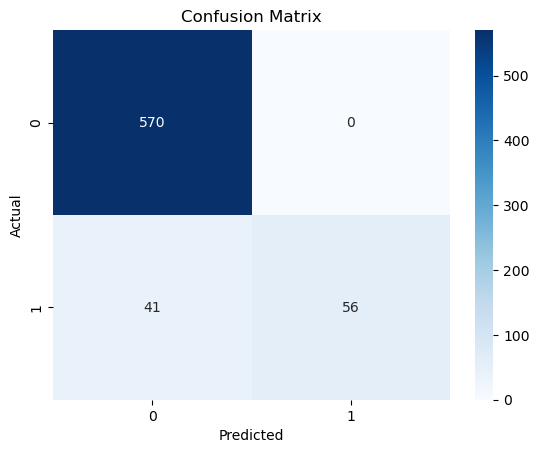

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Performance Comparison

- Logistic Regression provides a baseline linear model.
- Decision Tree captures non-linear relationships but may overfit.
- Random Forest shows improved performance by combining multiple decision trees.

Among the evaluated models, Random Forest provides the most balanced performance across precision, recall, and overall accuracy.